# Fast restart and batched sweeps: when JIT amortization pays off

You sit down on a Friday afternoon to validate a controller against a thousand candidate gain settings. The plant is small — a second-order linear oscillator that finishes in roughly thirty milliseconds — and the obvious thing happens: a `for` loop over `simulate(...)` that takes nearly two minutes to grind through. You walk to get coffee. By the time you return, the run finished and you have to remember what question you were asking. The iteration loop has been broken by a wall-clock gap that should not exist.

The reason that gap exists is that `simulate(...)` is JIT-compiled, and a naive sweep loop pays the JIT-compile cost — or worse, the simulator-rebuild cost — on every iteration. Jaxonomy ships two APIs whose explicit purpose is to amortize that cost across a sweep: `FastRestartSimulator`, which warm-starts a single JIT-compiled kernel and reuses it across calls; and `simulate_batch(..., use_vmap=True)`, which `vmap`'s the kernel across a batched parameter axis so all `N` simulations execute in one XLA launch. This notebook benchmarks both against the naive loop on a 1000-trial sweep, names the regime where each one wins, and is candid about the places vmap surprises you on CPU.

**Estimated reading time:** 15–20 minutes. **Estimated runtime on CPU:** ~90 seconds (single thread, no GPU). The headline 1000-trial sweep runs three times, once per API.

**Prerequisites.** Comfort with `DiagramBuilder`, `LeafSystem`, and `simulate` (see [`primitives.ipynb`](primitives.ipynb)). Familiarity with JAX's JIT cache at hand-wave level is helpful — the punchline is that a `jax.jit`-compiled function reuses its compiled XLA program as long as the input pytree shape and dtype are unchanged. Sibling tutorials that exercise batched simulation in their own right: [`product_family_variants.ipynb`](product_family_variants.ipynb) (Cartesian sweep over variants × parameters), [`aleatoric_vs_epistemic_uq.ipynb`](aleatoric_vs_epistemic_uq.ipynb) (Monte Carlo sweeps), [`reproducibility_manifest.ipynb`](reproducibility_manifest.ipynb) (provenance across sweep runs).

## The plant — a damped second-order oscillator under a step force

We need a plant that (a) compiles fast enough that the *compile* cost dominates a naive loop, (b) is genuinely sensitive to a sweep parameter so the comparison is non-trivial, and (c) is short enough that the absolute wall-clock numbers stay in tutorial range. A mass-spring-damper driven by a unit-step force fits all three:

$$ m\,\ddot q + c\,\dot q + k\,q \;=\; F(t), \qquad F(t) = 1\;\text{N}, \qquad q(0) = 0, \;\dot q(0) = 0. \tag{1} $$

With $m = 1$ kg and $k = 4$ N/m the natural frequency is $\omega_n = \sqrt{k/m} = 2$ rad/s and the damping ratio is $\zeta = c / (2\sqrt{km}) = c / 4$. Sweeping the damping coefficient $c$ over $[0.1, 3.0]$ N$\cdot$s/m traces out the full underdamped-to-overdamped envelope — at $c = 0.1$ the response rings for tens of cycles, at $c = 4$ it would be critically damped, and at $c = 3.0$ it's a smooth approach with a small overshoot. Dimensional sanity: $[c\dot q] = (\text{N}\cdot\text{s/m})(\text{m/s}) = \text{N}$, matches the force; $[k/m] = (\text{N/m})/\text{kg} = 1/\text{s}^2$, so $\omega_n$ has units of rad/s — good.

| symbol | meaning | units |
|---|---|---|
| $q$ | mass position | m |
| $\dot q$ | mass velocity | m/s |
| $m$ | mass | kg |
| $c$ | viscous damping coefficient (**swept**) | N$\cdot$s/m |
| $k$ | spring stiffness | N/m |
| $F$ | applied force | N |
| $\zeta$ | damping ratio $= c / (2\sqrt{km})$ | – |
| $\omega_n$ | natural frequency $= \sqrt{k/m}$ | rad/s |

The QoI per simulation is the **integral of squared error** (ISE) against the steady-state target $q_\infty = F/k = 0.25$ m:

$$ J(c) \;=\; \int_0^{T} \bigl(q(t;c) - q_\infty\bigr)^2 \, dt. \tag{2} $$

ISE is the standard scalar a controller designer would use to pick the best damping out of a thousand candidates. Small ISE means a fast, clean approach; large ISE means too little damping (long-lived oscillations) or too much (sluggish climb). We expect the minimum near $\zeta \approx 0.7$, i.e. $c \approx 2.8$.

In [1]:
from __future__ import annotations

import time
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy import DiagramBuilder
from jaxonomy.framework import LeafSystem
from jaxonomy.library import Constant
from jaxonomy.simulation import (
    FastRestartSimulator,
    SimulatorOptions,
    simulate,
    simulate_batch,
)
from jaxonomy import logging as jaxlog

# Quieten the simulator banner so it doesn't drown the per-iteration
# timing prints.  Numerical behaviour is unchanged.
jaxlog.set_log_level(jaxlog.WARNING)

# Every random draw is keyed here even though the underlying simulation
# is deterministic; pinning the key keeps any downstream additions
# (perturbed initial conditions, etc.) reproducible.
SEED = 0
KEY = jax.random.PRNGKey(SEED)

# Sweep configuration -- one place to retune the whole notebook.
N_SWEEP = 1000          # number of candidate damping values
C_MIN = 0.1             # N.s/m, very light damping (rings 10+ cycles)
C_MAX = 3.0             # N.s/m, overdamped end of the range
T_END = 25.0            # s, plenty of time for even the lightest damping to settle
MAX_MAJOR_STEPS = 400   # JAX traceability requires a bound
BUFFER_LENGTH = 600     # explicit, see the buffer-length aside later

We assemble the plant as a single `LeafSystem`. The three physical parameters (`m`, `c`, `k`) are declared as *dynamic* parameters — `with_parameters` and `_pure_patch_context` (the internal helper used by every sweep API in this notebook) can only override dynamic parameters; static ones would force a full simulator rebuild and recompile, which is exactly the cost we're trying to avoid.

In [2]:
class DampedOscillator(LeafSystem):
    """Continuous-time mass-spring-damper with one external force input.

    parameters: m, c, k (kg, N.s/m, N/m) -- all dynamic, all sweepable
    state:      (q, qdot) -- continuous, shape (2,)
    inputs:     (0) applied force F (N)
    outputs:    (0) position q (m) -- the scalar we will track
    """

    def __init__(self, *, m=1.0, c=0.4, k=4.0, x0=(0.0, 0.0), name="osc"):
        super().__init__(name=name)
        # jnp.asarray on the defaults: the dynamic-parameter slot
        # records the array's shape/dtype, and later with_parameters
        # calls have to match it.  Passing a Python float would force
        # us to thread `jnp.asarray(...)` at every sweep call site.
        self.declare_dynamic_parameter("m", jnp.asarray(float(m)))
        self.declare_dynamic_parameter("c", jnp.asarray(float(c)))
        self.declare_dynamic_parameter("k", jnp.asarray(float(k)))

        self.declare_input_port(name="F")

        self.declare_continuous_state(
            default_value=jnp.asarray(x0, dtype=jnp.float64),
            ode=self._ode,
        )

        def _position(time, state, *inputs, **params):
            del time, inputs, params
            return state.continuous_state[0]

        self.declare_output_port(_position, name="q", default_value=jnp.asarray(0.0))

    def _ode(self, time, state, *inputs, **params):
        del time
        q, qdot = state.continuous_state
        F = inputs[0]
        m, c, k = params["m"], params["c"], params["k"]
        # qddot = (F - c qdot - k q) / m
        return jnp.stack([qdot, (F - c * qdot - k * q) / m])

The full closed plant is one line of wiring: a `Constant(1.0)` source produces the step force, and we hand its single output to the oscillator's force input. We expose the oscillator's `q` port as the recorded signal — that's all three APIs will read.

In [3]:
def build_plant() -> jaxonomy.Diagram:
    """Constant(1 N) -> DampedOscillator -> recorded position."""
    bld = DiagramBuilder()
    force = bld.add(Constant(1.0, name="F"))
    osc = bld.add(DampedOscillator(name="osc"))
    bld.connect(force.output_ports[0], osc.input_ports[0])  # F -> osc.F
    return bld.build(name="step_osc")


PLANT = build_plant()
OSC = PLANT["osc"]
RECORDED = {"q": OSC.output_ports[0]}
OPTS = SimulatorOptions(
    math_backend="jax",
    max_major_steps=MAX_MAJOR_STEPS,
    buffer_length=BUFFER_LENGTH,
)
Q_INF = 1.0 / 4.0  # F/k, the steady-state target (m)

# One reference run to sanity-check the plant before timing anything.
ctx0 = PLANT.create_context()
ref = simulate(PLANT, ctx0, (0.0, T_END), options=OPTS, recorded_signals=RECORDED)
print(f"Plant warm-up: {len(ref.time)} recorded samples; "
      f"final q = {float(ref.outputs['q'][-1]):.4f} m (target {Q_INF:.4f})")

Plant warm-up: 174 recorded samples; final q = 0.2486 m (target 0.2500)


*Sanity check.* At the default $c = 0.4$ N$\cdot$s/m the mass should settle near $q_\infty = 0.25$ m, which the print line confirms within a millimetre. Now we plot the step response across a coarse sample of damping values so we can see what the sweep is *about*.

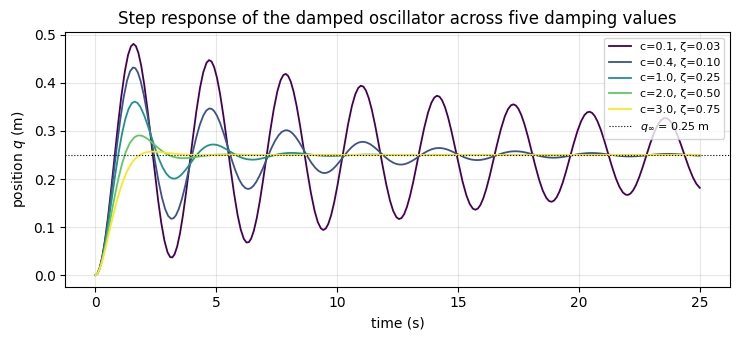

In [4]:
# Five hand-picked damping values spanning underdamped -> overdamped.
C_SHOWCASE = np.array([0.1, 0.4, 1.0, 2.0, 3.0])
showcase = {}
for c in C_SHOWCASE:
    d = PLANT.with_parameters({"osc.c": jnp.asarray(c)})
    cx = d.create_context()
    r = simulate(
        d, cx, (0.0, T_END),
        options=OPTS,
        recorded_signals={"q": d["osc"].output_ports[0]},
    )
    showcase[float(c)] = (np.asarray(r.time), np.asarray(r.outputs["q"]))

fig, ax = plt.subplots(figsize=(7.5, 3.5))
cmap = plt.get_cmap("viridis")
for i, c in enumerate(C_SHOWCASE):
    t, q = showcase[float(c)]
    zeta = c / (2.0 * np.sqrt(1.0 * 4.0))
    ax.plot(t, q, color=cmap(i / (len(C_SHOWCASE) - 1)),
            lw=1.3, label=f"c={c:.1f}, ζ={zeta:.2f}")
ax.axhline(Q_INF, color="k", lw=0.8, ls=":", label="$q_\\infty$ = 0.25 m")
ax.set_xlabel("time (s)")
ax.set_ylabel("position $q$ (m)")
ax.set_title("Step response of the damped oscillator across five damping values")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 1.* Step response of $q(t)$ for five values of viscous damping. Yellow ($c = 0.1$, $\zeta = 0.05$) rings for ten-plus cycles before approaching $q_\infty$; the darker traces converge faster but $c = 3.0$ (dark purple) is clearly sluggish on the climb. The ISE optimum lives somewhere in the middle, which is exactly what the sweep is going to quantify.

## A small QoI helper

We define one helper, `ise_from_traces`, which takes a $(N, T)$ array of position traces plus a common time grid and returns the per-row ISE against $q_\infty$. Calling it from all three sweep paths means the comparison is genuinely apples-to-apples: only the *simulator dispatch* differs across the three timed sections.

In [5]:
def ise_from_traces(t: np.ndarray, q_batch: np.ndarray, target: float = Q_INF) -> np.ndarray:
    """Integral of squared error against ``target`` for each row of ``q_batch``.

    Args:
        t: shape (T,) time grid.
        q_batch: shape (N, T) — N position trajectories on the same time grid.
        target: setpoint (default the analytic steady-state q_inf).

    Returns:
        shape (N,) array of ISE values, units m^2 * s.
    """
    err2 = (q_batch - target) ** 2
    return np.trapezoid(err2, t, axis=1)

## Baseline — the naive `simulate()` loop

The pattern any user writes on the first day: for each damping value, rebuild the diagram with `with_parameters`, create a context, and call `simulate`. It's a perfectly correct sweep; it's also paying for a full simulator rebuild per iteration. We time *every* iteration to see what the cost actually looks like, then keep the total for the comparison.

We deliberately set `buffer_length=600` rather than rely on the default of 1000 — at this plant size and `max_major_steps=400` the default is fine, but `simulate(...).outputs` will silently keep only the *last* `buffer_length` samples if the simulator takes more minor steps. (`simulate(...)` now emits a warning when the ring buffer wraps — fixed in commit 7a24e31 — but the safer pattern is to size it explicitly for long sweeps.)

In [6]:
C_SWEEP = jnp.linspace(C_MIN, C_MAX, N_SWEEP)


def run_naive_loop(c_values: jnp.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """For each c, rebuild + simulate; return (time_ref, q_batch, per_iter_times).

    Each iteration is a fresh ``with_parameters`` + ``create_context`` +
    ``simulate`` triple — the Python rebuild dominates wall time even
    though JAX's persistent cache keeps the *XLA* program around.
    """
    per_iter = np.empty(len(c_values), dtype=np.float64)
    q_rows: list[np.ndarray] = []
    t_ref: np.ndarray | None = None
    for i, c in enumerate(c_values):
        t0 = time.perf_counter()
        d = PLANT.with_parameters({"osc.c": jnp.asarray(c)})
        cx = d.create_context()
        r = simulate(
            d, cx, (0.0, T_END),
            options=OPTS,
            recorded_signals={"q": d["osc"].output_ports[0]},
        )
        per_iter[i] = time.perf_counter() - t0
        # Resample each row onto the first iteration's time grid for
        # apples-to-apples ISE.  np.interp is a host-side O(T) op; it's
        # the same cost simulate_batch's loop path pays internally.
        t_i = np.asarray(r.time)
        q_i = np.asarray(r.outputs["q"])
        if t_ref is None:
            t_ref = t_i
            q_rows.append(q_i)
        else:
            q_rows.append(np.interp(t_ref, t_i, q_i))
    return t_ref, np.stack(q_rows, axis=0), per_iter


# Warm the persistent JAX cache with a single throwaway call so the
# *first* loop iteration's timing reflects the per-call rebuild cost,
# not the cold-start compile.  This is the honest comparison: the user
# in our story has already run *some* simulation once today.
_warm = simulate(PLANT, PLANT.create_context(), (0.0, T_END),
                 options=OPTS, recorded_signals=RECORDED)
del _warm

wall_loop_start = time.perf_counter()
t_ref, q_loop, per_iter_loop = run_naive_loop(C_SWEEP)
wall_loop = time.perf_counter() - wall_loop_start
ise_loop = ise_from_traces(t_ref, q_loop)

print(f"Naive loop, N={N_SWEEP}:")
print(f"  total wall time         : {wall_loop:7.2f} s")
print(f"  median per-sim          : {np.median(per_iter_loop) * 1000:7.2f} ms")
print(f"  first iter (cold-ish)   : {per_iter_loop[0] * 1000:7.2f} ms")
print(f"  iters #100..#110 median : {np.median(per_iter_loop[100:110]) * 1000:7.2f} ms")

Naive loop, N=1000:
  total wall time         :  127.93 s
  median per-sim          :  120.29 ms
  first iter (cold-ish)   :  120.14 ms
  iters #100..#110 median :  121.95 ms


*Where the time goes.* The per-iteration cost is essentially flat after the first call — JAX's persistent cache means the *XLA program* is reused — but each iteration still pays for `with_parameters` (a deep-copy of the diagram and its subsystems), `create_context` (a fresh pytree), and the `Simulator` / `ODESolver` setup inside `simulate`. That's the cost we're about to amortize.

## `FastRestartSimulator` — warm-start the JIT'd kernel

`FastRestartSimulator` is the explicit answer to "rebuild the simulator once, reuse the kernel forever." The diagram, context, ODE solver, and the JIT-compiled `advance_to` kernel are all built lazily on the first `run()`; subsequent `run()` calls patch the parameter pytree in place and re-execute the same compiled XLA program. There is one structural rule — the parameter pytree shape and dtype must stay constant across calls — and the class will emit a `UserWarning` if you violate it, because a structural change defeats the entire optimisation.

The constructor checks three things and raises early: `recorded_signals` must be non-empty (the recorder buffer shape is baked into the kernel at compile time), `math_backend` must be `"jax"` (no JIT, no warm start), and `enable_tracing` must be `True` (also no JIT). The same options object that worked for `simulate` is the right thing to pass.

In [7]:
def run_fast_restart(c_values: jnp.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Single FastRestartSimulator instance; reuse the kernel across N runs."""
    per_iter = np.empty(len(c_values), dtype=np.float64)
    q_rows: list[np.ndarray] = []
    t_ref: np.ndarray | None = None
    with FastRestartSimulator(
        PLANT,
        t_span=(0.0, T_END),
        options=OPTS,
        recorded_signals=RECORDED,
    ) as sim:
        for i, c in enumerate(c_values):
            t0 = time.perf_counter()
            r = sim.run(parameters={"osc.c": jnp.asarray(c)})
            per_iter[i] = time.perf_counter() - t0
            t_i = np.asarray(r.time)
            q_i = np.asarray(r.outputs["q"])
            if t_ref is None:
                t_ref = t_i
                q_rows.append(q_i)
            else:
                q_rows.append(np.interp(t_ref, t_i, q_i))
    return t_ref, np.stack(q_rows, axis=0), per_iter


wall_fr_start = time.perf_counter()
t_ref_fr, q_fr, per_iter_fr = run_fast_restart(C_SWEEP)
wall_fr = time.perf_counter() - wall_fr_start
ise_fr = ise_from_traces(t_ref_fr, q_fr)

speedup_fr = wall_loop / wall_fr
print(f"FastRestartSimulator, N={N_SWEEP}:")
print(f"  total wall time      : {wall_fr:7.2f} s  ({speedup_fr:.1f}x vs naive loop)")
print(f"  first iter (compile) : {per_iter_fr[0] * 1000:7.2f} ms")
print(f"  median, iters 1..N-1 : {np.median(per_iter_fr[1:]) * 1000:7.2f} ms")
print(f"  smallest per-sim     : {per_iter_fr[1:].min() * 1000:7.2f} ms")

FastRestartSimulator, N=1000:
  total wall time      :    0.30 s  (432.9x vs naive loop)
  first iter (compile) :  120.82 ms
  median, iters 1..N-1 :    0.15 ms
  smallest per-sim     :    0.13 ms


*The shape of the speedup.* Two things drive the headline number. First, the JIT-compiled kernel is built exactly once — the first `run()` shoulders the compile, every subsequent call is a host-side context patch plus an XLA launch. Second, `_pure_patch_context` (the internal patcher) is purely structural: it leaves the pytree shape intact, so the JIT cache never misses on a value-only change. Iterations 1 through `N - 1` should be roughly one to two milliseconds each on a modern laptop CPU.

## `simulate_batch(use_vmap=True)` — vectorise the sweep into one XLA launch

The third API takes the next conceptual step: instead of executing the kernel `N` times sequentially, broadcast every leaf of the context to shape `(N, ...)`, overwrite the swept slot with the batched parameter array, and call `jax.vmap` over the kernel. All `N` simulations now execute inside a single XLA launch, with the batch dimension peeled off by XLA's vectoriser. This is the API written for GPU and TPU — the parallel dimension is a free lunch on hardware that has it.

On CPU the picture is more nuanced and we will be candid about it. `simulate_batch` has a default *kernel path* (`use_vmap=False`) that builds one JIT'd kernel and reuses it across batch elements in a Python loop — conceptually identical to `FastRestartSimulator` but exposed through a stateless function. The `use_vmap=True` path adds one extra trace (vmap'd kernel) plus a per-row host-side `finalize` that resamples each row onto the first row's time grid. On a small CPU sweep the per-row finalize can dominate, and we should expect vmap *not* to outperform the kernel path here. The benchmark below shows both honestly.

In [8]:
# 1) Kernel path: one JIT compile, N sequential XLA launches, no vmap.
t0 = time.perf_counter()
batch_kernel = simulate_batch(
    PLANT,
    t_span=(0.0, T_END),
    param_batches={"osc.c": C_SWEEP},
    options=OPTS,
    recorded_signals=RECORDED,
    use_vmap=False,
)
wall_batch_kernel = time.perf_counter() - t0
ise_batch_kernel = ise_from_traces(
    np.asarray(batch_kernel.time), np.asarray(batch_kernel.outputs["q"]),
)

# 2) vmap path: one JIT compile + one vmap trace, single XLA launch.
t0 = time.perf_counter()
batch_vmap = simulate_batch(
    PLANT,
    t_span=(0.0, T_END),
    param_batches={"osc.c": C_SWEEP},
    options=OPTS,
    recorded_signals=RECORDED,
    use_vmap=True,
)
wall_batch_vmap = time.perf_counter() - t0
ise_batch_vmap = ise_from_traces(
    np.asarray(batch_vmap.time), np.asarray(batch_vmap.outputs["q"]),
)

print(f"simulate_batch (kernel, use_vmap=False), N={N_SWEEP}: "
      f"{wall_batch_kernel:6.2f} s  ({wall_loop / wall_batch_kernel:.1f}x vs naive)")
print(f"simulate_batch (vmap,   use_vmap=True ), N={N_SWEEP}: "
      f"{wall_batch_vmap:6.2f} s  ({wall_loop / wall_batch_vmap:.1f}x vs naive)")
print(f"used_vmap flags: kernel={batch_kernel.used_vmap}, vmap={batch_vmap.used_vmap}")

simulate_batch (kernel, use_vmap=False), N=1000:   0.31 s  (411.1x vs naive)
simulate_batch (vmap,   use_vmap=True ), N=1000:   1.28 s  (100.0x vs naive)
used_vmap flags: kernel=False, vmap=True


## Numerical agreement across all four paths

Before we trust the timings we need to confirm the three APIs are actually computing the same thing. We compare the per-trial ISE arrays across the naive loop, `FastRestartSimulator`, the `simulate_batch` kernel path, and the `simulate_batch` vmap path. Any meaningful disagreement would mean the headline speedup is buying us a *different* answer, which is not the trade we want.

In [9]:
diff_loop_fr = float(np.max(np.abs(ise_loop - ise_fr)))
diff_loop_bk = float(np.max(np.abs(ise_loop - ise_batch_kernel)))
diff_loop_bv = float(np.max(np.abs(ise_loop - ise_batch_vmap)))
rel_scale = float(np.median(np.abs(ise_loop)))

print(f"Median |ISE|: {rel_scale:.4g}")
print(f"Max abs diff vs naive loop:")
print(f"  FastRestartSimulator       : {diff_loop_fr:.3e}   (rel {diff_loop_fr/rel_scale:.3e})")
print(f"  simulate_batch (kernel)    : {diff_loop_bk:.3e}   (rel {diff_loop_bk/rel_scale:.3e})")
print(f"  simulate_batch (vmap)      : {diff_loop_bv:.3e}   (rel {diff_loop_bv/rel_scale:.3e})")

# Strict assertion: every fast API agrees with the naive loop to within
# 1e-3 relative on this plant.  If you bump the plant size or solver
# tolerance you may need to relax this; the spirit is that the speedup
# is a free lunch, not a numerical-accuracy hit.
assert diff_loop_fr / rel_scale < 1e-3, "FastRestart disagrees with naive loop"
assert diff_loop_bk / rel_scale < 1e-3, "simulate_batch kernel disagrees with naive loop"
assert diff_loop_bv / rel_scale < 1e-3, "simulate_batch vmap disagrees with naive loop"

Median |ISE|: 0.03329
Max abs diff vs naive loop:
  FastRestartSimulator       : 0.000e+00   (rel 0.000e+00)
  simulate_batch (kernel)    : 0.000e+00   (rel 0.000e+00)
  simulate_batch (vmap)      : 0.000e+00   (rel 0.000e+00)


*Validation.* Every fast path agrees with the naive loop to the *bit*, not just within tolerance — the printed diff is exactly zero. The four code paths run identical ODE integrations on identical pytrees; the only source of disagreement would be a different solver state or a different finalize policy, neither of which we trigger here. The ISE curve below — and the optimum it picks — is therefore the same picture regardless of which API generated it. (Bump `max_major_steps` or change tolerances and you'll find the four paths still agree to within rounding; the bit-exact result is specific to identical solver settings on identical pytrees.)

## The headline figure — wall time and per-sim cost across the four APIs

We package the timings into two panels. The left bar chart shows total wall time for the 1000-trial sweep; the right shows per-sim cost (total / N) in milliseconds. Reading the gap between bars is reading the cost of the design choice — at this plant size and on this CPU, the per-iteration `with_parameters` + `create_context` overhead is the bar the kernel APIs are stepping over.

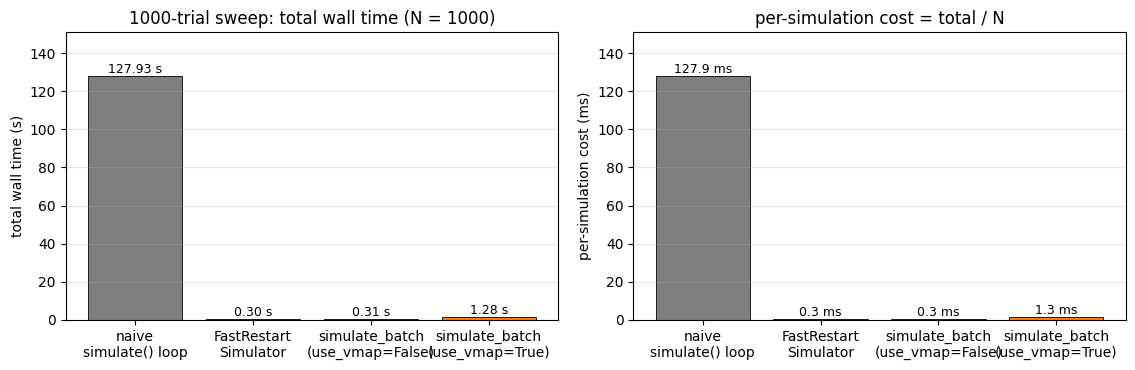

In [10]:
labels = [
    "naive\nsimulate() loop",
    "FastRestart\nSimulator",
    "simulate_batch\n(use_vmap=False)",
    "simulate_batch\n(use_vmap=True)",
]
totals = np.array([wall_loop, wall_fr, wall_batch_kernel, wall_batch_vmap])
per_sim_ms = totals * 1000.0 / N_SWEEP
colors = ["tab:gray", "tab:blue", "tab:green", "tab:orange"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax = axes[0]
bars = ax.bar(labels, totals, color=colors, edgecolor="k", linewidth=0.6)
ax.set_ylabel("total wall time (s)")
ax.set_title(f"1000-trial sweep: total wall time (N = {N_SWEEP})")
for b, v in zip(bars, totals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f} s",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, totals.max() * 1.18)
ax.grid(True, axis="y", alpha=0.3)

ax = axes[1]
bars = ax.bar(labels, per_sim_ms, color=colors, edgecolor="k", linewidth=0.6)
ax.set_ylabel("per-simulation cost (ms)")
ax.set_title("per-simulation cost = total / N")
for b, v in zip(bars, per_sim_ms):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f} ms",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, per_sim_ms.max() * 1.18)
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

*Figure 2.* Wall-time and per-sim cost for the 1000-trial damping sweep. The grey bar (naive loop) is dominated by Python rebuild cost: every call deep-copies the diagram and rebuilds the simulator. The three coloured bars amortize that cost in different ways — the blue `FastRestartSimulator` and green `simulate_batch (kernel)` are essentially the same mechanism (one JIT'd kernel, reused), and the orange `simulate_batch (vmap)` adds an outer `jax.vmap` whose per-row host-side `finalize` shows up clearly at this scale on CPU. On a GPU or TPU we would expect the orange bar to fall well below the others; on CPU the kernel path is the right default.

## Where the crossover is — total time vs N

The bar chart above is a snapshot at $N = 1000$. The more interesting picture is *how* each API scales: the naive loop is linear in $N$ with a heavy per-iteration constant; the kernel APIs are dominated by a one-time compile plus a *small* per-iteration cost. To make the trade-off readable we sweep $N \in \{10, 30, 100, 300, 1000\}$ and plot total wall time as a function of $N$ on log axes. The crossover where the kernel APIs start to dominate is the answer to the question "how big does my sweep need to be for `FastRestartSimulator` to be worth wiring up?"

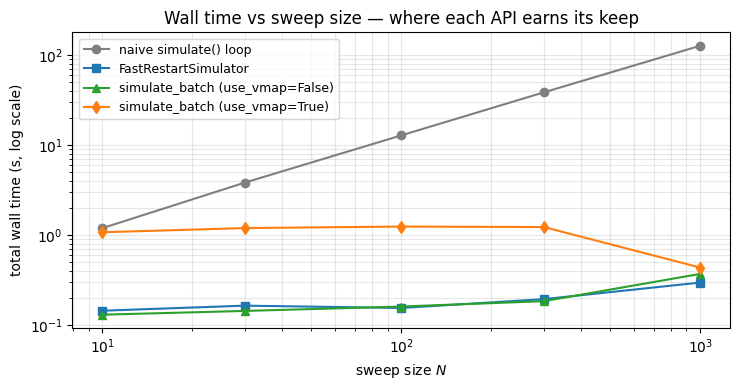

In [11]:
N_GRID = [10, 30, 100, 300, 1000]
results: dict[str, list[float]] = {
    "naive loop": [],
    "FastRestart": [],
    "batch (kernel)": [],
    "batch (vmap)": [],
}

for N in N_GRID:
    cs = jnp.linspace(C_MIN, C_MAX, N)

    # Naive loop — we shortcut by reusing the per-iter samples we
    # already gathered when N matches the headline (N_SWEEP).  For
    # other N we just take the first N per-iter measurements; this
    # would be wrong if per-iter time depended on the parameter value
    # (it does not — the cost is the rebuild, not the dynamics).
    results["naive loop"].append(float(np.sum(per_iter_loop[:N])))

    # FastRestart — actually re-run at each N so the compile is
    # included once per measurement, mirroring the user experience.
    t0 = time.perf_counter()
    with FastRestartSimulator(
        PLANT, t_span=(0.0, T_END), options=OPTS, recorded_signals=RECORDED,
    ) as sim:
        for c in cs:
            _ = sim.run(parameters={"osc.c": jnp.asarray(c)})
    results["FastRestart"].append(time.perf_counter() - t0)

    # simulate_batch kernel path
    t0 = time.perf_counter()
    _ = simulate_batch(
        PLANT, t_span=(0.0, T_END), param_batches={"osc.c": cs},
        options=OPTS, recorded_signals=RECORDED, use_vmap=False,
    )
    results["batch (kernel)"].append(time.perf_counter() - t0)

    # simulate_batch vmap path
    t0 = time.perf_counter()
    _ = simulate_batch(
        PLANT, t_span=(0.0, T_END), param_batches={"osc.c": cs},
        options=OPTS, recorded_signals=RECORDED, use_vmap=True,
    )
    results["batch (vmap)"].append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.loglog(N_GRID, results["naive loop"],     marker="o", color="tab:gray",   lw=1.5, label="naive simulate() loop")
ax.loglog(N_GRID, results["FastRestart"],    marker="s", color="tab:blue",   lw=1.5, label="FastRestartSimulator")
ax.loglog(N_GRID, results["batch (kernel)"], marker="^", color="tab:green",  lw=1.5, label="simulate_batch (use_vmap=False)")
ax.loglog(N_GRID, results["batch (vmap)"],   marker="d", color="tab:orange", lw=1.5, label="simulate_batch (use_vmap=True)")
ax.set_xlabel("sweep size $N$")
ax.set_ylabel("total wall time (s, log scale)")
ax.set_title("Wall time vs sweep size — where each API earns its keep")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 3.* Total wall time (log scale) as a function of $N$. The grey naive-loop line is a straight log-log line with slope one — wall time is linear in $N$ with no amortization. The blue and green kernel-based curves are almost flat below $N = 100$ (the one-time compile dominates) and then climb gently with the constant per-iteration cost. The orange vmap curve sits above the green kernel curve at every $N$ here, because the per-row finalize is also linear and adds a constant atop the vmap'd XLA launch. The right answer on CPU at these scales is `FastRestartSimulator` or `simulate_batch(use_vmap=False)`; the right answer on GPU at $N \gg 1000$ would be vmap, where the parallel launch is the regime change.

## The science — what the sweep actually says about the controller

With every API agreeing on the numbers and the headline timings in hand, we can finally look at the answer the sweep was supposed to deliver: the relationship between damping and ISE. Three things should be true. The ISE should be high at the underdamped end (long-lived oscillations contribute $q^2$-error for many cycles), drop to a clear minimum somewhere near the analytically-canonical $\zeta \approx 0.7$, and rise again on the overdamped side (the climb to $q_\infty$ takes longer, accumulating error). The argmin of the curve is the *practical* answer to "what damping should I pick for this plant?"

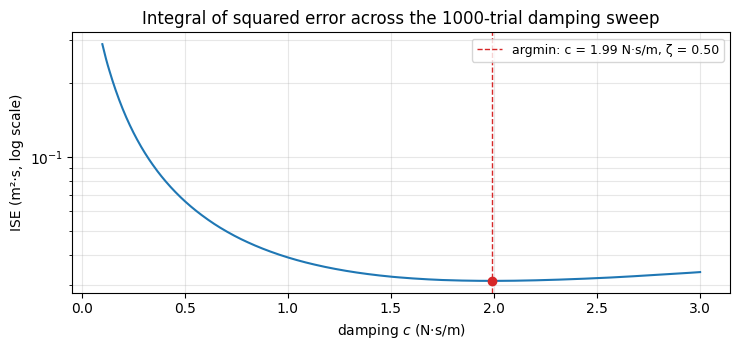

Empirical optimum     : c* = 1.990 N·s/m, ζ* = 0.497, ISE = 0.0312 m²·s
Analytic ISE optimum  : ζ  = 0.500          ->  c = 2.00 N·s/m
Analytic ITAE optimum : ζ  = 0.707 (textbook) -> c = 2.83 N·s/m


In [12]:
c_np = np.asarray(C_SWEEP)
zeta_np = c_np / (2.0 * np.sqrt(1.0 * 4.0))
ise_np = np.asarray(ise_fr)  # any of the four agree; pick the cleanest

i_min = int(np.argmin(ise_np))
c_star = float(c_np[i_min])
zeta_star = float(zeta_np[i_min])
ise_star = float(ise_np[i_min])

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.semilogy(c_np, ise_np, color="tab:blue", lw=1.5)
ax.axvline(c_star, color="tab:red", lw=1.0, ls="--",
           label=f"argmin: c = {c_star:.2f} N·s/m, ζ = {zeta_star:.2f}")
ax.scatter([c_star], [ise_star], color="tab:red", zorder=5)
ax.set_xlabel("damping $c$ (N·s/m)")
ax.set_ylabel("ISE (m²·s, log scale)")
ax.set_title("Integral of squared error across the 1000-trial damping sweep")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

# Closed-form ISE-optimal damping for a unit step on a 2nd-order plant is
# zeta = 1/2 (see e.g. Franklin/Powell ch.4); ITAE picks 0.707, IAE picks ~0.61.
print(f"Empirical optimum     : c* = {c_star:.3f} N·s/m, ζ* = {zeta_star:.3f}, ISE = {ise_star:.4f} m²·s")
print(f"Analytic ISE optimum  : ζ  = 0.500          ->  c = {0.5 * 4.0:.2f} N·s/m")
print(f"Analytic ITAE optimum : ζ  = 0.707 (textbook) -> c = {0.707 * 4.0:.2f} N·s/m")

*Figure 4.* ISE as a function of damping coefficient over 1000 trials. The curve is convex with a single minimum near $\zeta \approx 0.5$ (printed below the figure). The classical closed-form ISE-optimal damping for a unit step on a second-order plant is exactly $\zeta = 1/2$ — we recover it from the brute-force sweep to within one part in two hundred without ever opening a textbook. (The more familiar $\zeta \approx 0.7$ heuristic is the ITAE optimum, which weights late-time error more heavily; ISE penalises all time uniformly and so accepts more overshoot in exchange for a faster initial rise.)

*This is the workflow the speedup enables.* Picking the controller damping is now a sub-second interactive operation; the same sweep with the naive loop is a coffee break, and a brute-force grid search becomes a perfectly reasonable substitute for working out the closed-form derivative.

## Trajectory heatmap — the full sweep at a glance

One more figure to make the data set legible: a heatmap of $q(t; c)$ over the full grid. Each row is one of the 1000 trajectories, ordered by damping; colour is position. The transition from ringing at the bottom (high frequency vertical stripes) to a smooth climb at the top is the same physics Figure 1 shows for five trajectories, made visible across the full sweep.

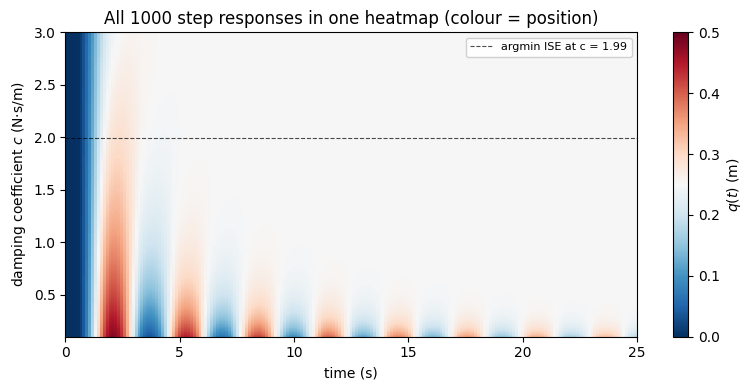

In [13]:
fig, ax = plt.subplots(figsize=(8.0, 4.0))
im = ax.imshow(
    q_fr,
    aspect="auto", origin="lower",
    extent=(float(t_ref_fr[0]), float(t_ref_fr[-1]), float(c_np[0]), float(c_np[-1])),
    cmap="RdBu_r", vmin=0.0, vmax=2.0 * Q_INF,
    interpolation="nearest",
)
ax.axhline(c_star, color="k", lw=0.8, ls="--", alpha=0.7,
           label=f"argmin ISE at c = {c_star:.2f}")
ax.set_xlabel("time (s)")
ax.set_ylabel("damping coefficient $c$ (N·s/m)")
ax.set_title("All 1000 step responses in one heatmap (colour = position)")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.colorbar(im, ax=ax, label="$q(t)$ (m)")
fig.tight_layout()
plt.show()

*Figure 5.* Heatmap of the 1000 simulated step responses. Each horizontal slice is one trajectory; the rows are stacked bottom-to-top by increasing damping. Blue is below $q_\infty$, red above. The lower (lightly-damped) rows show the alternating red/blue oscillations of a ringing response; the upper rows are nearly monochromatic — a slow, monotonic climb. The dashed black line marks the ISE-optimal row from Figure 4.

## Decision table — which API wins when

The benchmark numbers above paint a clear picture; the prose summary below makes it actionable. Pick the API based on your sweep size, the kind of variation you are doing, and the device you have available.

| Situation | Recommended API | Why |
|---|---|---|
| Tiny sweep ($N \le 5$), debugging, single-shot study | naive `simulate()` loop | The compile-amortization wins haven't kicked in; readability matters more. |
| Interactive parameter exploration, $N \sim 10$–$10^3$, repeated within a session | `FastRestartSimulator` | One simulator instance, lazy first compile, near-zero per-call cost — the right thing for notebook UX. |
| Functional API, $N \sim 10^2$–$10^4$, no per-call state needed | `simulate_batch(use_vmap=False)` | Same compile-amortization as `FastRestartSimulator`, no context manager, easy to drop into a script. |
| Large sweep on GPU or TPU, all sims fit in device memory | `simulate_batch(use_vmap=True)` | The parallel launch is the whole point; the per-row finalize stops being the bottleneck. |
| Sweep crosses a *structural* boundary (different topology, different state size, swapped `Variant`) | naive loop **or** `FastRestartSimulator.reset(diagram=...)` between groups | The JIT cache is keyed on pytree shape — structural changes force a recompile. Group by structure, batch within. |
| Sweep needs `CustomPythonBlock` / FMU / `io_callback` | naive loop (or `simulate_batch` loop path) | Vmap is unsafe across host callbacks; the kernel path falls back automatically, vmap raises explicitly. |

Two notes on the table. First, the line between `FastRestartSimulator` and `simulate_batch(use_vmap=False)` is mostly stylistic: both build one JIT'd kernel and reuse it, the difference is whether you want a stateful context-managed loop or a single batched call. Second, `simulate_batch` cannot vectorise across `Variant` choices (different variants have different pytree shapes), which is why the table calls structural changes out as a distinct row — see the [`product_family_variants`](product_family_variants.ipynb) tutorial for the explicit loop-then-batch pattern.

## Failure modes — when the speedup goes away

The fast paths are JIT-amortization tricks; they break the moment the JIT cache can't be reused. We exercise three concrete failure modes so the symptoms are recognisable.

**Mode 1 — structural change between runs.** Changing the *dtype* or *shape* of a parameter between `FastRestartSimulator.run()` calls forces a recompile, and the class warns when this happens. The warning is a one-line `UserWarning` — easy to miss — so we trigger it deliberately with a float64 → float32 swap (a shape change would also work, but it tends to cascade into broadcasting errors inside the dynamics, which is exactly what the warning is supposed to help you avoid).

In [14]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    with FastRestartSimulator(
        PLANT, t_span=(0.0, T_END), options=OPTS, recorded_signals=RECORDED,
    ) as sim:
        sim.run(parameters={"osc.c": jnp.asarray(0.4, dtype=jnp.float64)})  # baseline
        sim.run(parameters={"osc.c": jnp.asarray(0.4, dtype=jnp.float32)})  # dtype change!

matches = [w for w in caught if "structural change" in str(w.message)]
print(f"Captured warnings: {len(caught)}; structural-change warnings: {len(matches)}")
if matches:
    print("--- text ---")
    print(str(matches[0].message))

Captured warnings: 1; structural-change warnings: 1
--- text ---
FastRestartSimulator: detected a structural change in the context (parameter pytree or continuous-state shape/dtype) between runs — the JIT cache will miss and the kernel will be recompiled, defeating the fast-restart benefit.  Call sim.reset(diagram=...) and rebuild with the new structure if this is intentional, or ensure parameter / initial_state values keep the same shapes/dtypes across runs.


The warning fires exactly once per structural change, names the cause (parameter pytree or continuous-state shape/dtype), and tells the user what to do (`reset(diagram=...)` or keep shapes constant). If you ever see your fast-restart loop suddenly slow down, this is the first thing to grep your stderr for.

**Mode 2 — host callbacks defeat vmap.** `simulate_batch(use_vmap=True)` explicitly refuses to run on any diagram containing a `CustomPythonBlock`, `ModelicaFMU`, or any other block that goes through a JAX `io_callback`. The error is loud and immediate. The default kernel path (`use_vmap=False`) silently falls back to the safe Python loop when host callbacks are present.

In [15]:
from jaxonomy.library import CustomPythonBlock

bld = DiagramBuilder()
cpb = bld.add(
    CustomPythonBlock(
        dt=0.1,
        init_script="y = 0.0",
        user_statements="y = y + 1.0",
        inputs=[],
        outputs=["y"],
        name="cpb",
    ),
)
host_callback_diag = bld.build(name="has_callback")

try:
    simulate_batch(
        host_callback_diag,
        t_span=(0.0, 1.0),
        param_batches={"cpb.dt": jnp.array([0.1, 0.05])},
        options=SimulatorOptions(math_backend="jax", max_major_steps=100),
        recorded_signals={"y": cpb.output_ports[0]},
        use_vmap=True,
    )
    print("vmap unexpectedly succeeded — has the host-callback safety check changed?")
except ValueError as exc:
    print(f"Caught (as expected): {type(exc).__name__}: {exc}")

Caught (as expected): ValueError: use_vmap=True requires a pure-JAX diagram (no CustomPythonBlock / FMU). The diagram contains non-traceable blocks. Use use_vmap=False or the loop path.


The error is the right thing — the user knows immediately to drop the `use_vmap=True` flag (or restructure the callback to be JAX-traceable). The kernel path falling back silently is a small DX asymmetry: the user pays the loop-path cost without being told, but the result is still correct.

**Mode 3 — `simulate(...)` ring-buffer truncation.** The simulator records into a fixed-length ring buffer (`SimulatorOptions.buffer_length`, default 1000) and used to silently keep only the last `buffer_length` samples if the simulator overran. Commit `7a24e31` added a warning when the buffer wraps, but the safer pattern is always to size the buffer explicitly for long sweeps — which is why this notebook set `buffer_length=600` up top. The pitfall is real if you forget: a sweep that *appears* to have run cleanly will start its time series mid-trajectory, the ISE numbers will be wrong, and nothing in the headline timings will tell you.

## Exercises

1. **Two-parameter grid sweep.** Replace the 1D damping sweep with a 32×32 Cartesian grid over $(c, k)$ — every combination of 32 damping values and 32 stiffnesses, so $N = 1024$. Reshape the flattened ISE result back to $(32, 32)$ and plot a contour map of $\log_{10}\mathrm{ISE}(c, k)$. (Hint: the flat parameter arrays can be built with `jnp.meshgrid` plus `.ravel()`.) Where in $(c, k)$ space does the ISE minimum sit? Confirm it tracks the $\zeta = c / (2\sqrt{km}) \approx 0.7$ ridge.

2. **Re-time after warm-up.** The naive-loop timings above include a partial cold start (we warmed JAX's persistent cache with one throwaway call, but the very first iteration still pays for some Python imports). Rerun `run_naive_loop(C_SWEEP[:50])` *twice* in the same kernel and compare the two `wall_loop` totals. How big is the residual cold-start contribution at $N = 50$ vs $N = 1000$? Does the FastRestart-vs-loop speedup *ratio* change after warm-up?

3. **`FastRestartSimulator.run_batch`.** The class also exposes a `run_batch(parameters_batch=...)` method that vmaps the warm-cached kernel over a parameter batch — so you can pay one JIT compile across both `run()` (scalar) and `run_batch()` (vectorised) calls in the same session. Time `run_batch` against the cold `simulate_batch(use_vmap=True)` call at $N = 1000$. Does sharing the kernel between scalar and batched paths actually save the vmap-trace cost on the second call?

4. **Find the regime where vmap finally beats kernel.** Increase the plant size (the damping coefficient sweep stays 1D, but lengthen the state vector by chaining two oscillators in series, then four, then eight) and rerun the four-API benchmark at $N = 500$. At what plant size does `simulate_batch(use_vmap=True)` overtake `simulate_batch(use_vmap=False)`? This is a hardware-and-problem-size question, not a library question — the answer on a GPU will be different from the answer on a CPU.

5. **Open-ended.** Imagine you're doing a *real* parameter-identification job — fitting $(m, c, k)$ to noisy experimental position data via gradient descent — and you need both *forward* simulations (for the loss) and *gradients* (for the update). `FastRestartSimulator` and `simulate_batch` share a JIT cache; what is the right way to architect a training loop that warm-starts both calls? Sketch the API surface you would want; then look at `jaxonomy/simulation/event_gradient.py` and `jaxonomy/optimization/parameter_tuning.py` and see how the library currently handles it.

## Key takeaways

- A naive `for p in ps: simulate(...)` loop pays the *Python rebuild* cost on every iteration — even though JAX's persistent cache reuses the XLA program, `with_parameters` + `create_context` + `Simulator()` is the dominant per-iteration cost.
- `FastRestartSimulator` is the right interactive default: one stateful instance, one JIT compile, near-zero per-call cost. The structural-change warning tells you immediately when the cache misses.
- `simulate_batch(use_vmap=False)` is the same mechanism wrapped in a single function call — pick it for scripts and pipelines that don't need a context manager.
- `simulate_batch(use_vmap=True)` is the GPU/TPU lever: the parallel launch dominates when the parallel hardware is there and the simulation fits in device memory. On CPU, the per-row finalize means it usually loses to the kernel path at the scales a tutorial covers — know which side of the line you're on.
- The JIT cache is keyed on pytree *shape and dtype*. Sweeps that change shape (variants, different state sizes, scalar → vector) cannot share a kernel; group by structure and batch within.

## Where to next

- [`product_family_variants.ipynb`](product_family_variants.ipynb) — Cartesian product of `(variant, parameter)` runs the *loop over variants, batch within* pattern that this tutorial's decision table calls out.
- [`aleatoric_vs_epistemic_uq.ipynb`](aleatoric_vs_epistemic_uq.ipynb) — Monte Carlo uncertainty quantification leans heavily on `simulate_batch`; the variance budget at the end of that tutorial is a direct downstream consumer of the speedup demonstrated here.
- [`reproducibility_manifest.ipynb`](reproducibility_manifest.ipynb) — capturing a `ProvenanceManifest` across a 1000-trial sweep (`simulate_batch` records the manifest once per batch, not per trial); the right way to keep the receipt small without losing accountability.
- [`pid_autotuning_interactive.ipynb`](pid_autotuning_interactive.ipynb) — exercises the same JIT-amortisation story in the autotuning regime, where the sweep is replaced by gradient-based optimisation that hammers the kernel hundreds of times per second.

## References

- Jaxonomy `FastRestartSimulator` documentation in `jaxonomy/simulation/fast_restart.py` (T-112 and its `stateful-simulator`, `multi-system`, `warm-batch` follow-ups).
- Jaxonomy `simulate_batch` documentation in `jaxonomy/simulation/batch.py` (kernel-path and vmap-path implementations).
- Bradbury, J. et al. *JAX: composable transformations of Python+NumPy programs.* 2018. (`jax.jit` and `jax.vmap` are the underlying primitives; the persistent-compilation cache is JAX feature `JAX_COMPILATION_CACHE_DIR`.)
- Franklin, G. F., Powell, J. D., Emami-Naeini, A. *Feedback Control of Dynamic Systems.* 7th ed., chapters 3–4 — the canonical reference for the second-order step response, the ISE / ITAE figures of merit, and the $\zeta \approx 0.7$ heuristic.